In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

%matplotlib inline

In [7]:
df = pd.read_csv("../data/processed/customer_reviews_product_clustered.csv")

print(df.head())
df.shape

                                        product_name       asins   brand  \
0  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
1  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
2  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
3  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   
4  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...  B01AHB9CN2  Amazon   

                                          categories manufacturer  \
0  Electronics,iPad & Tablets,All Tablets,Fire Ta...       Amazon   
1  Electronics,iPad & Tablets,All Tablets,Fire Ta...       Amazon   
2  Electronics,iPad & Tablets,All Tablets,Fire Ta...       Amazon   
3  Electronics,iPad & Tablets,All Tablets,Fire Ta...       Amazon   
4  Electronics,iPad & Tablets,All Tablets,Fire Ta...       Amazon   

                reviews.date reviews.doRecommend  reviews.numHelpful  \
0  2017-01-13 00:00:00+00:00                 yes        

(34614, 20)

In [11]:
# Prepare the date column

df["reviews.date"] = pd.to_datetime(
    df["reviews.date"],
    errors="coerce",
    utc=True
) 

df["reviews.date"].min(), df["reviews.date"].max()

(Timestamp('2011-11-18 00:00:00+0000', tz='UTC'),
 Timestamp('2018-04-18 00:00:00+0000', tz='UTC'))

# Visualization 1: Sentiment Distribution

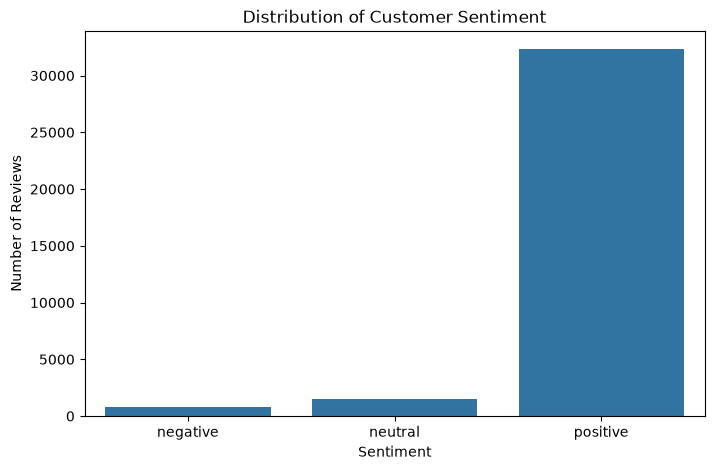

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["negative", "neutral", "positive"]
)

plt.title("Distribution of Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

The sentiment distribution is highly imbalanced, with positive reviews representing the majority of the dataset. Negative and neutral reviews occur much less frequently. This imbalance should be considered when interpreting category-level sentiment comparisons.

# Visualization 2: Star Rating Distribution

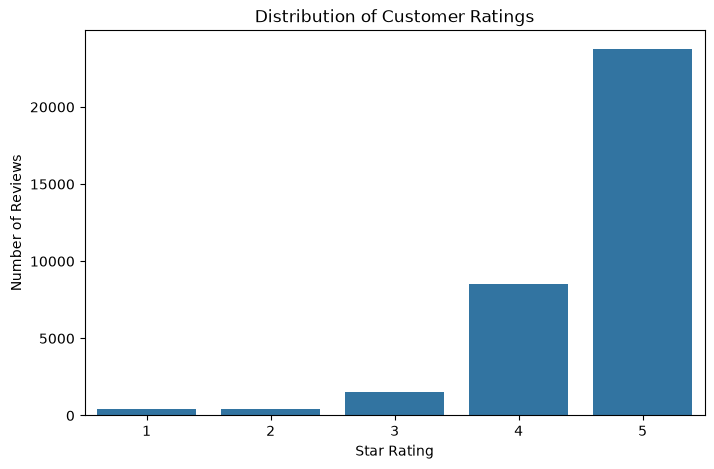

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="reviews.rating",
    order=[1, 2, 3, 4, 5]
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")

plt.show()

The dataset is dominated by 4- and 5-star reviews, which explains the high proportion of positive sentiment.

# Visualization 3: Number of Reviews per Category

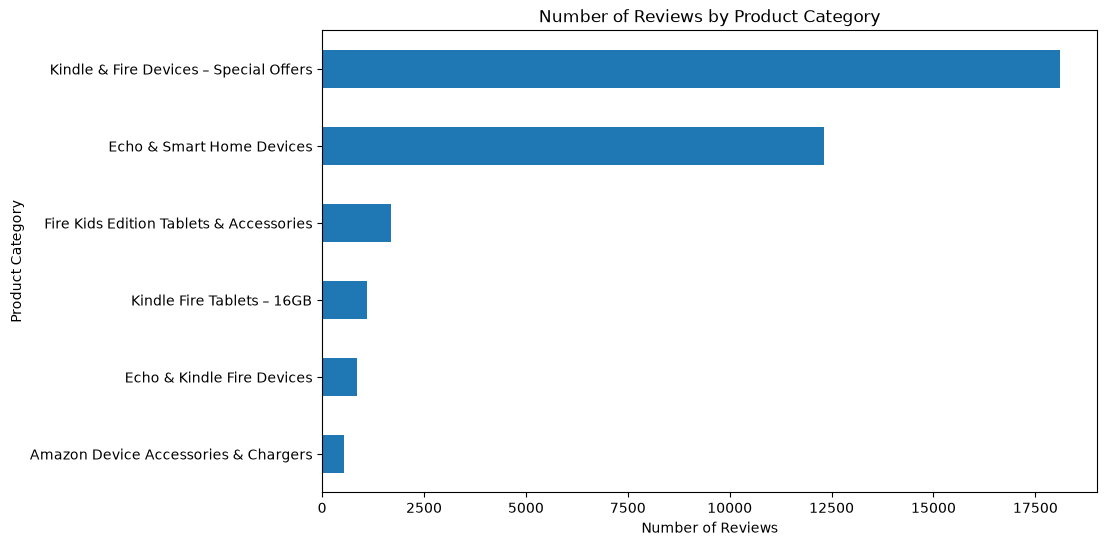

In [14]:
category_counts = (
    df["meta_category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

category_counts.plot(kind="barh")

plt.title("Number of Reviews by Product Category")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Category")

plt.show()

# Average Rating by Category

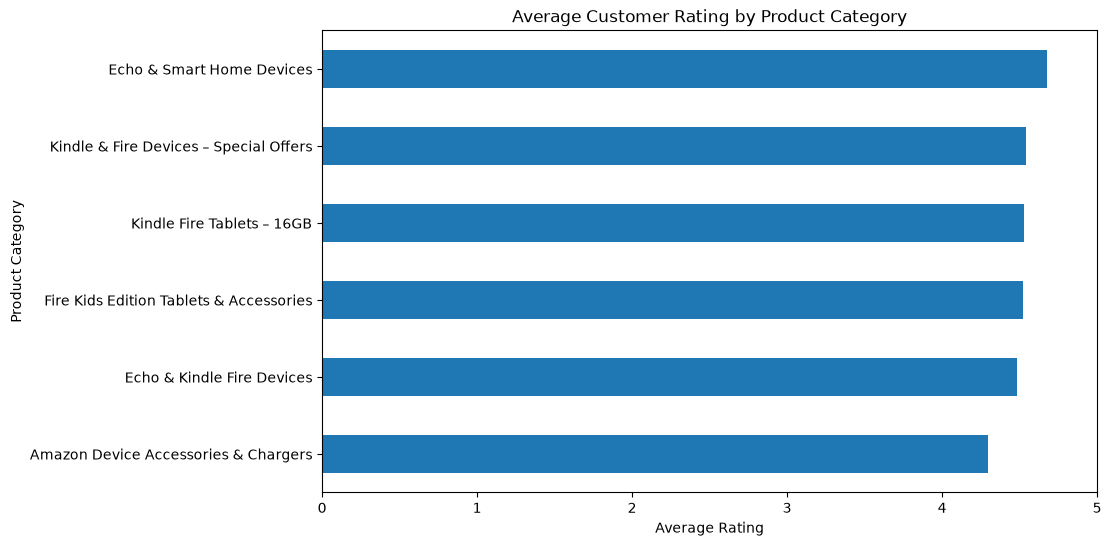

In [15]:
category_rating = (
    df.groupby("meta_category")["reviews.rating"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

category_rating.plot(kind="barh")

plt.title("Average Customer Rating by Product Category")
plt.xlabel("Average Rating")
plt.ylabel("Product Category")

plt.xlim(0, 5)

plt.show()

| Category                                | Average rating |
| --------------------------------------- | -------------: |
| Echo & Smart Home Devices               |           4.68 |
| Kindle & Fire Devices – Special Offers  |           4.54 |
| Kindle Fire Tablets – 16GB              |           4.53 |
| Fire Kids Edition Tablets & Accessories |           4.52 |
| Echo & Kindle Fire Devices              |           4.48 |
| Amazon Device Accessories & Chargers    |           4.30 |


Amazon Device Accessories & Chargers has the lowest average rating.

## Visualization 5: Sentiment by Category 

# Which product category has the most negative reviews?

In [16]:
sentiment_category = pd.crosstab(
    df["meta_category"],
    df["sentiment"],
    normalize="index"
) * 100

sentiment_category

sentiment,negative,neutral,positive
meta_category,,,
Amazon Device Accessories & Chargers,12.969925,5.075188,81.954887
Echo & Kindle Fire Devices,3.391813,6.549708,90.058480
Echo & Smart Home Devices,1.509985,3.239162,95.250852
Fire Kids Edition Tablets & Accessories,3.419811,5.542453,91.037736
Kindle & Fire Devices – Special Offers,2.396598,4.837374,92.766028
Kindle Fire Tablets – 16GB,3.079710,4.257246,92.663043


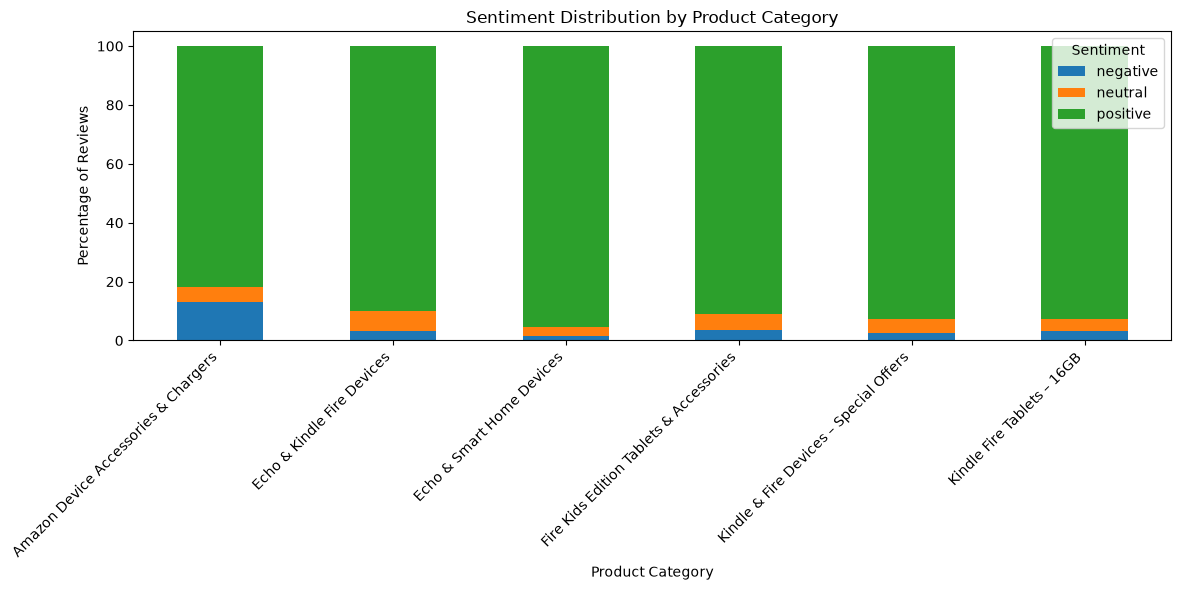

In [17]:
sentiment_category[
    ["negative", "neutral", "positive"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Sentiment Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

This is much better than simply counting negative reviews, because your categories contain very different numbers of reviews.

## Visualization 6: Category × Sentiment Heatmap

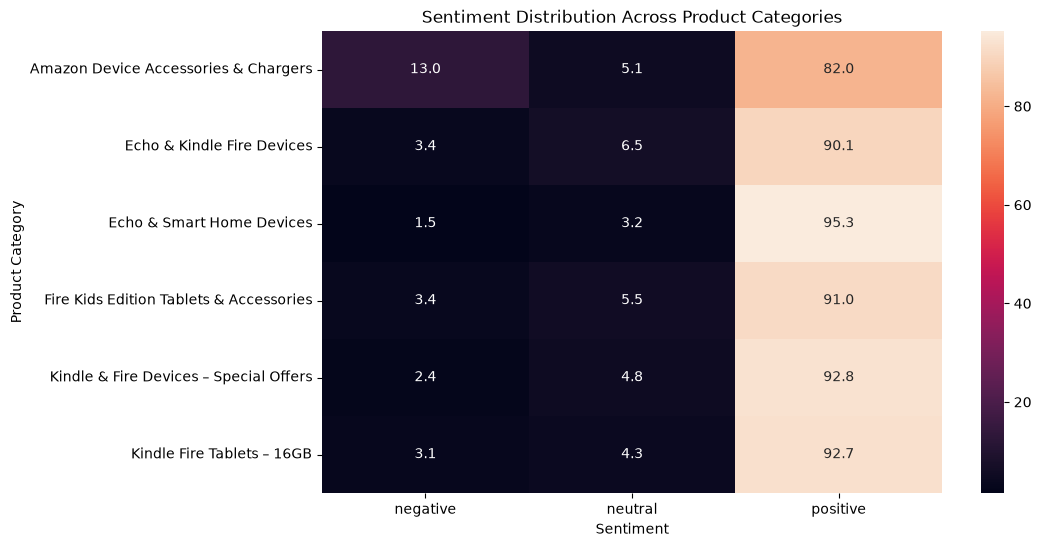

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    sentiment_category,
    annot=True,
    fmt=".1f"
)

plt.title("Sentiment Distribution Across Product Categories")
plt.xlabel("Sentiment")
plt.ylabel("Product Category")

plt.show()

# Visualization 7: Rating Distribution by Category

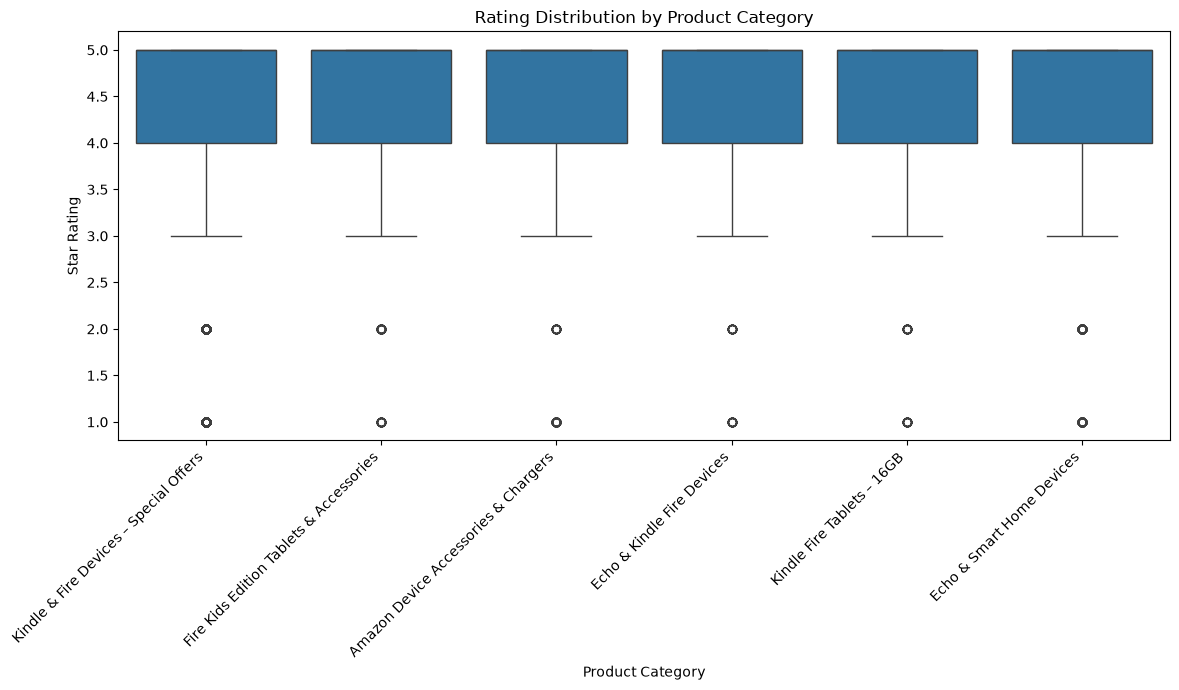

In [19]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="meta_category",
    y="reviews.rating"
)

plt.title("Rating Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

This shows:
median rating
spread
outliers
differences between categories

# Visualization 8: Top Products by Number of Reviews

) missing from font(s) DejaVu Sans.on\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


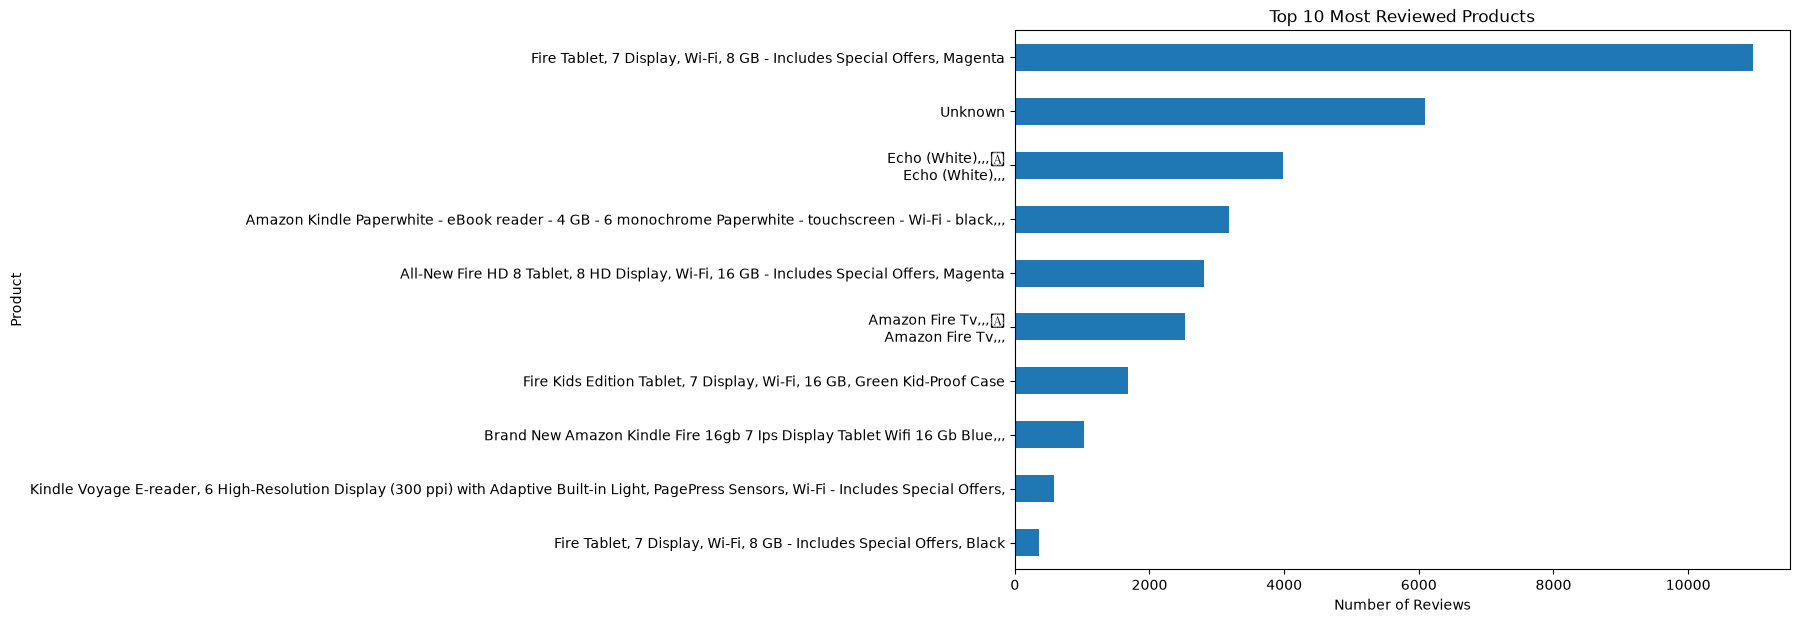

In [21]:
top_products = (
    df.groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 7))

top_products.plot(kind="barh")

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.show()

Some products have thousands of reviews.

# Visualization 9: Top Products by Average Rating

In [23]:
product_stats = (
    df.groupby("product_name")
    .agg(
        review_count=("reviews.rating", "count"),
        average_rating=("reviews.rating", "mean")
    )
)

reliable_products = (
    product_stats[
        product_stats["review_count"] >= 50
    ]
    .sort_values("average_rating", ascending=False)
)

) missing from font(s) DejaVu Sans.on\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


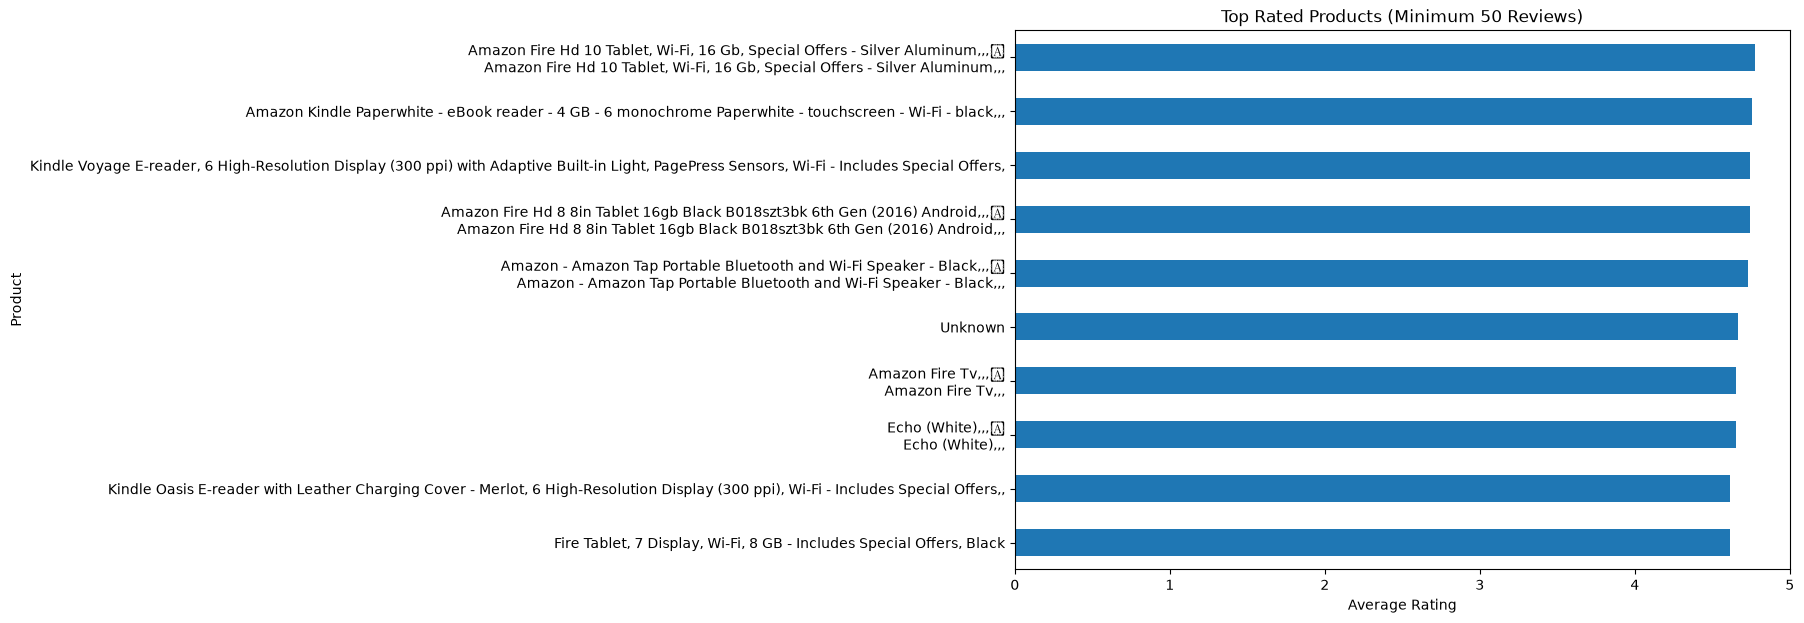

In [24]:
top_rated = reliable_products.head(10).sort_values(
    "average_rating"
)

plt.figure(figsize=(10, 7))

top_rated["average_rating"].plot(kind="barh")

plt.title("Top Rated Products (Minimum 50 Reviews)")
plt.xlabel("Average Rating")
plt.ylabel("Product")

plt.xlim(0, 5)

plt.show()

# Visualization 10: Worst Products

) missing from font(s) DejaVu Sans.on\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


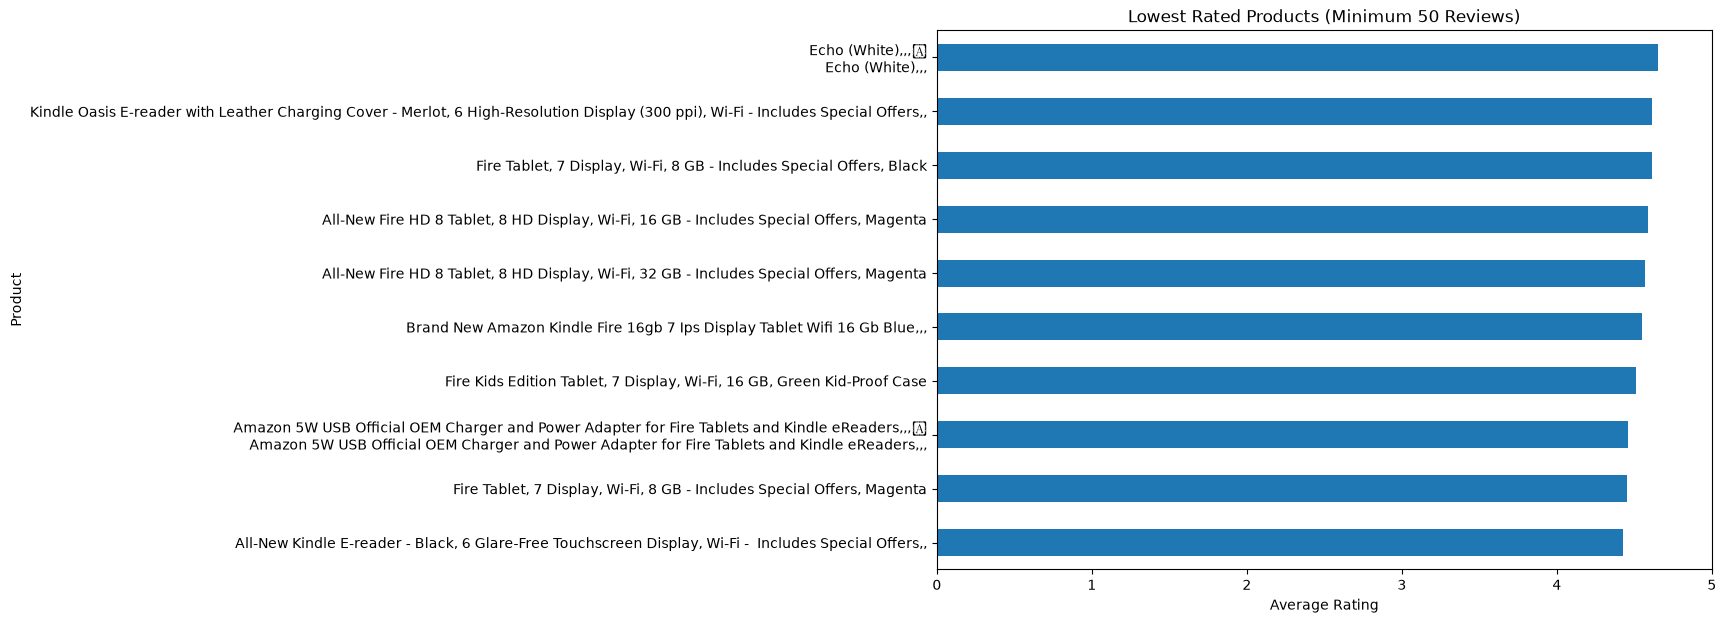

In [25]:
worst_rated = reliable_products.tail(10).sort_values(
    "average_rating"
)

plt.figure(figsize=(10, 7))

worst_rated["average_rating"].plot(kind="barh")

plt.title("Lowest Rated Products (Minimum 50 Reviews)")
plt.xlabel("Average Rating")
plt.ylabel("Product")

plt.xlim(0, 5)

plt.show()

# Visualization 11: Sentiment Over Time

In [26]:
df["month"] = df["reviews.date"].dt.to_period("M")

monthly_sentiment = (
    df.groupby(["month", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

C:\Users\anita\AppData\Local\Temp\ipykernel_25164\3039155995.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["reviews.date"].dt.to_period("M")


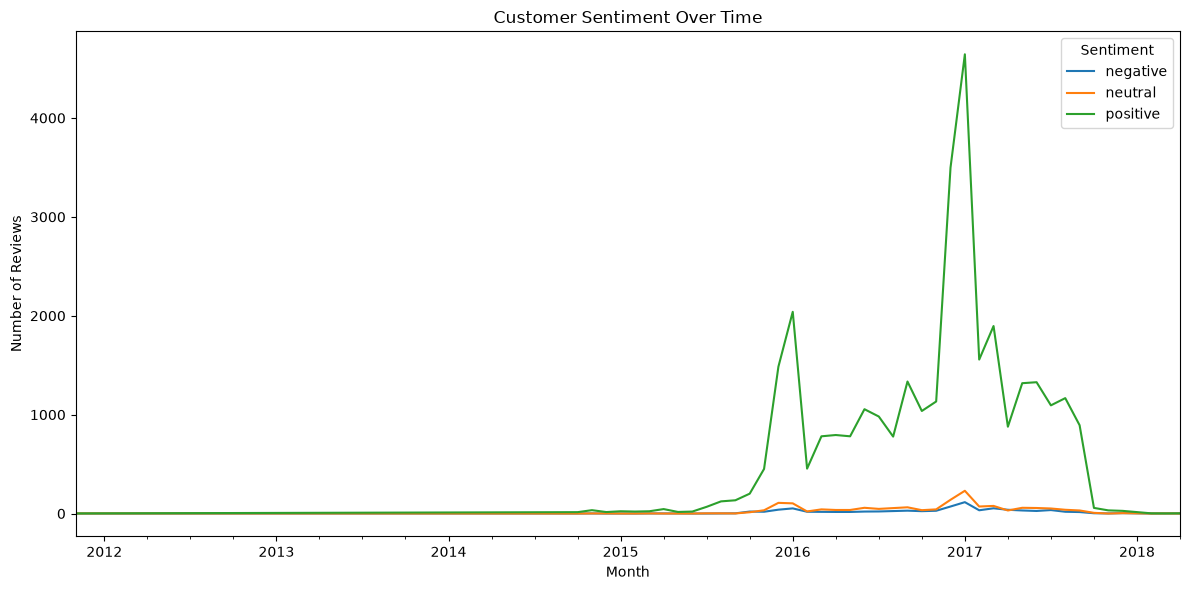

In [27]:
monthly_sentiment.plot(
    figsize=(12, 6)
)

plt.title("Customer Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

# Visualization 12: Average Rating Over Time

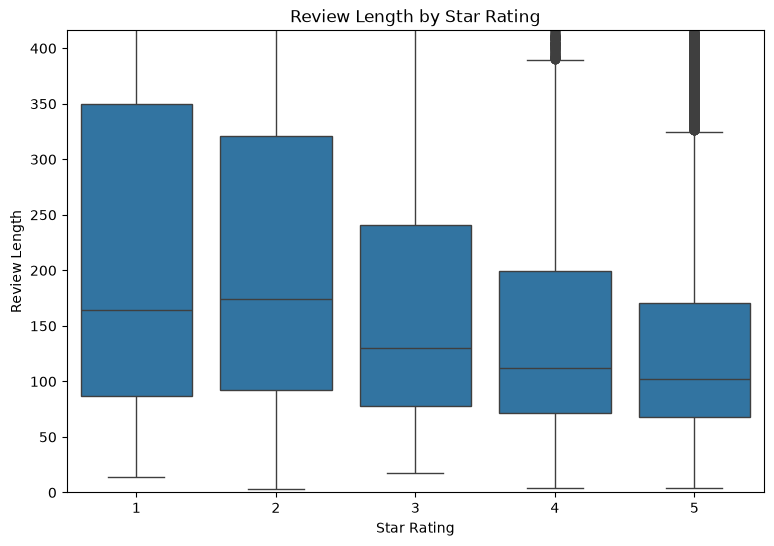

In [28]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="reviews.rating",
    y="text_length"
)

plt.title("Review Length by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Review Length")

plt.ylim(0, df["text_length"].quantile(0.95))

plt.show()

# Visualization 14: Helpful Reviews

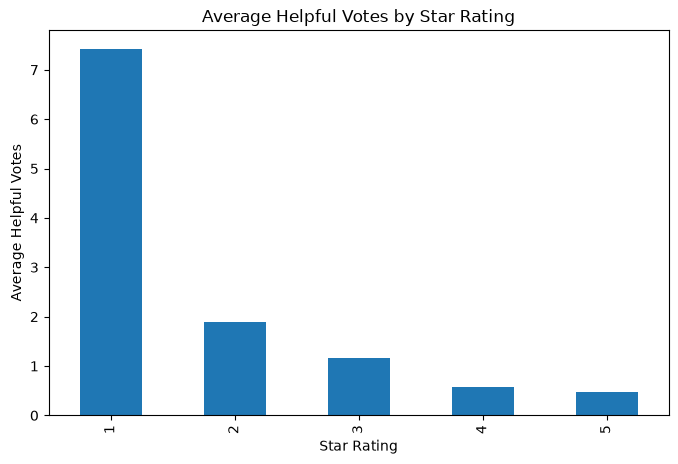

In [29]:
helpful_by_rating = (
    df.groupby("reviews.rating")["reviews.numHelpful"]
    .mean()
)

plt.figure(figsize=(8, 5))

helpful_by_rating.plot(kind="bar")

plt.title("Average Helpful Votes by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Helpful Votes")

plt.show()

In [30]:
df[
    [
        "product_name",
        "reviews.rating",
        "reviews.numHelpful",
        "sentiment",
        "reviews.text"
    ]
].sort_values(
    "reviews.numHelpful",
    ascending=False
).head(10)

,product_name,reviews.rating,reviews.numHelpful,sentiment,reviews.text
28902,Unknown,5,814.0,positive,IMPORTANT UPDATE (3/8/17): As you read my orig...
21188,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",5,780.0,positive,"Since the Fire TV stick was announced, I've he..."
34581,Unknown,4,744.0,positive,"Hey Alexa, Hey Alexa - Night and day it's Hey ..."
21189,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",5,740.0,positive,UPDATE! 11/11/15: More than a year now of usin...
2882,"Amazon Kindle Lighted Leather Cover,,,\r\nAmaz...",3,730.0,neutral,"I owned a Kindle Keyboard for about a year, an..."
34579,Unknown,5,660.0,positive,This review is more of a guide for cablecutter...
21187,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",5,650.0,positive,I was fortunate to order one of these as soon ...
28624,Unknown,4,629.0,positive,"These days, Amazon doesn't supply a charger wh..."
29335,Unknown,5,434.0,positive,It was just a few weeks ago that I was bemoani...
28626,Unknown,1,422.0,negative,This is clearly taking advantaged of Kindle cu...


# Complaint Analysis

In [31]:
negative_reviews = df[
    df["sentiment"] == "negative"
].copy()

print(negative_reviews.shape)

(810, 21)


# Extract Common Complaint Words

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    min_df=3,
    max_features=30
)

X = vectorizer.fit_transform(
    negative_reviews["clean_text"].fillna("")
)

word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": np.asarray(X.sum(axis=0)).ravel()
})

word_counts = word_counts.sort_values(
    "count",
    ascending=False
)

word_counts.head(20)

,word,count
0,amazon,304
26,tablet,274
4,bought,159
17,kindle,155
16,just,151
28,use,146
5,buy,140
18,like,124
27,time,121
2,apps,121


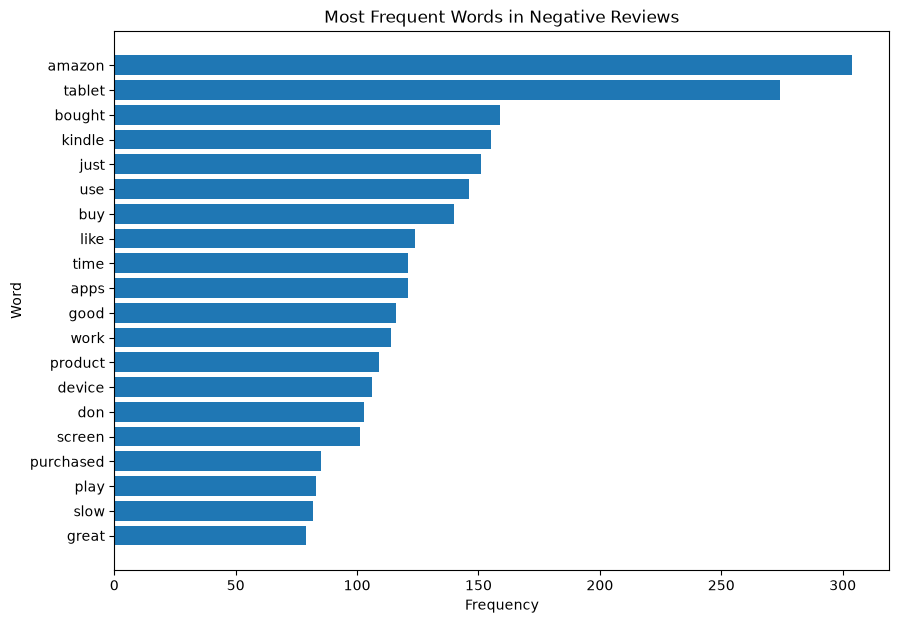

In [33]:
top_words = word_counts.head(20).sort_values("count")

plt.figure(figsize=(10, 7))

plt.barh(
    top_words["word"],
    top_words["count"]
)

plt.title("Most Frequent Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

# Complaint Analysis by Category

In [36]:
for category in df["meta_category"].unique():

    category_negative = df[
        (df["meta_category"] == category) &
        (df["sentiment"] == "negative")
    ]

    print("\nCATEGORY:")
    print(category)
    print("Negative reviews:", len(category_negative))



CATEGORY:
Kindle & Fire Devices – Special Offers
Negative reviews: 434

CATEGORY:
Fire Kids Edition Tablets & Accessories
Negative reviews: 58

CATEGORY:
Amazon Device Accessories & Chargers
Negative reviews: 69

CATEGORY:
Echo & Kindle Fire Devices
Negative reviews: 29

CATEGORY:
Kindle Fire Tablets – 16GB
Negative reviews: 34

CATEGORY:
Echo & Smart Home Devices
Negative reviews: 186


# Extract complaint words for each category

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

categories = df["meta_category"].dropna().unique()

for category in categories:

    # Get negative reviews for this category
    category_negative = df[
        (df["meta_category"] == category) &
        (df["sentiment"] == "negative")
    ].copy()

    print("\n" + "=" * 70)
    print("CATEGORY:", category)
    print("Negative reviews:", len(category_negative))
    print("=" * 70)

    # Skip if there are too few reviews
    if len(category_negative) < 5:
        print("Not enough negative reviews.")
        continue

    # Create TF/count vectorizer
    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=2,
        max_features=15
    )

    X = vectorizer.fit_transform(
        category_negative["clean_text"].fillna("")
    )

    # Count words
    word_counts = pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "count": X.sum(axis=0).A1
    })

    word_counts = word_counts.sort_values(
        "count",
        ascending=False
    )

    print(word_counts.to_string(index=False))


CATEGORY: Kindle & Fire Devices – Special Offers
Negative reviews: 434
   word  count
 tablet    214
 amazon    153
 bought     94
   apps     88
    buy     84
    use     82
 screen     75
   just     73
   like     73
 kindle     72
   good     66
   slow     62
product     58
   time     58
   work     52

CATEGORY: Fire Kids Edition Tablets & Accessories
Negative reviews: 58
   word  count
 tablet     23
   time     21
 amazon     15
   apps     15
   year     14
   kids     13
 charge     13
    buy     12
   free     12
product     11
 bought     11
    use     11
   like     11
   work     11
    kid     10

CATEGORY: Amazon Device Accessories & Chargers
Negative reviews: 69
   word  count
 kindle     64
charger     62
 charge     20
 amazon     20
   just     18
  cover     15
   fast     14
    use     13
  power     13
  doesn     12
    don     12
    usb     12
    buy     11
 bought     11
   plug     10

CATEGORY: Echo & Kindle Fire Devices
Negative reviews: 29
       w

Improve the complaint-word extraction

remove additional generic words.

In [38]:
custom_stopwords = [
    "amazon",
    "product",
    "item",
    "thing",
    "stuff",
    "use",
    "used",
    "using",
    "really",
    "just",
    "good",
    "great",
    "nice",
    "like",
    "got",
    "get",
    "buy",
    "bought",
    "purchase",
    "purchased",
    "one",
    "also",
    "would",
    "could",
    "did",
    "does",
    "dont",
    "didnt",
    "ive",
    "im",
    "its",
    "they",
    "them"
]

In [39]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    max_features=20
)

In [40]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

all_stopwords = list(
    ENGLISH_STOP_WORDS.union(custom_stopwords)
)

In [41]:
vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    min_df=2,
    max_features=20
)

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

for category in categories:

    category_negative = df[
        (df["meta_category"] == category) &
        (df["sentiment"] == "negative")
    ].copy()

    print("\n" + "=" * 70)
    print("CATEGORY:", category)
    print("Negative reviews:", len(category_negative))
    print("=" * 70)

    if len(category_negative) < 5:
        continue

    vectorizer = CountVectorizer(
        stop_words=all_stopwords,
        ngram_range=(1, 2),
        min_df=2,
        max_features=20
    )

    X = vectorizer.fit_transform(
        category_negative["clean_text"].fillna("")
    )

    phrase_counts = pd.DataFrame({
        "term": vectorizer.get_feature_names_out(),
        "count": X.sum(axis=0).A1
    })

    phrase_counts = phrase_counts.sort_values(
        "count",
        ascending=False
    )

    print(phrase_counts.to_string(index=False))


CATEGORY: Kindle & Fire Devices – Special Offers
Negative reviews: 434
    term  count
  tablet    214
    apps     88
  screen     75
  kindle     72
    slow     62
    time     58
    work     52
  device     49
     don     48
    best     44
   store     41
   books     40
   price     40
    didn     40
    play     40
   games     39
     app     38
  google     35
returned     35
    kids     33

CATEGORY: Fire Kids Edition Tablets & Accessories
Negative reviews: 58
     term  count
   tablet     23
     time     21
     apps     15
     year     14
   charge     13
     kids     13
     free     12
     work     11
     play     10
      kid     10
     ipad     10
      don     10
      old      9
    games      8
     slow      8
  charger      7
 daughter      7
free time      7
  tablets      7
    times      7

CATEGORY: Amazon Device Accessories & Chargers
Negative reviews: 69
        term  count
      kindle     64
     charger     62
      charge     20
       cover  

In [44]:
category = "Amazon Device Accessories & Chargers"

category_negative = df[
    (df["meta_category"] == category) &
    (df["sentiment"] == "negative")
].copy()

vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1, 2),
    min_df=2,
    max_features=15
)

X = vectorizer.fit_transform(
    category_negative["clean_text"].fillna("")
)

phrase_counts = pd.DataFrame({
    "term": vectorizer.get_feature_names_out(),
    "count": X.sum(axis=0).A1
})

phrase_counts = phrase_counts.sort_values(
    "count",
    ascending=True
)

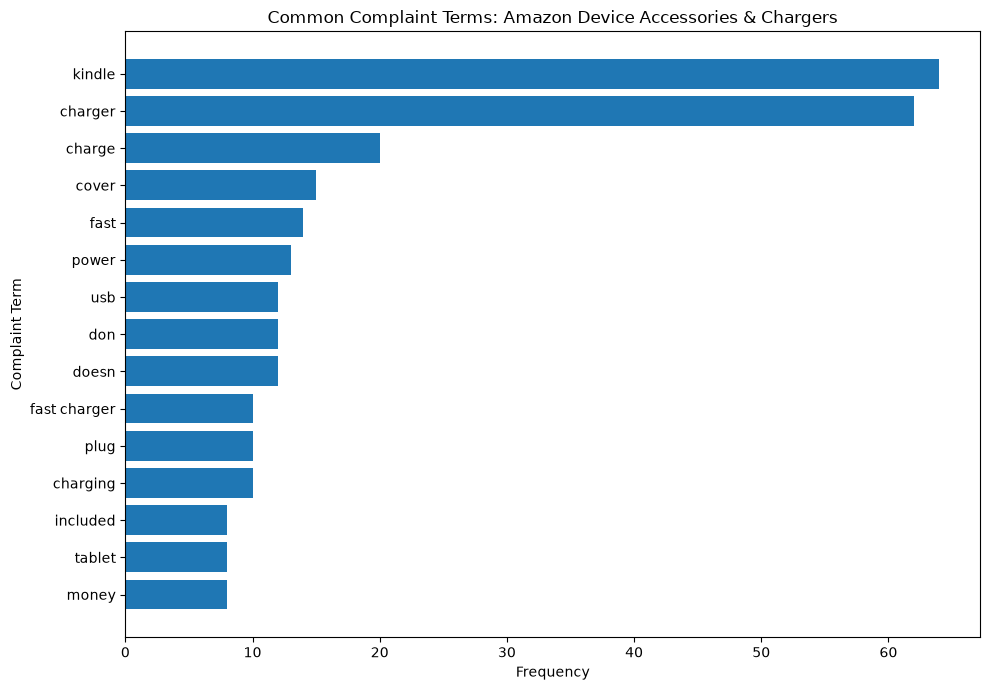

In [45]:
plt.figure(figsize=(10, 7))

plt.barh(
    phrase_counts["term"],
    phrase_counts["count"]
)

plt.title(
    f"Common Complaint Terms: {category}"
)

plt.xlabel("Frequency")
plt.ylabel("Complaint Term")

plt.tight_layout()
plt.show()